In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from iminuit import Minuit, cost
from scipy.stats import genextreme


colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')


save_figures = True

In [77]:
# Load Data
filename="gev-mu=70,alpha=10,gamma=0.3,N=e5.csv"
directory = "data"
directory_figures="../Figures"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")
df   = pd.read_csv(filepath)

data = np.array(df.values[:,0])
data;

Filepath: data/gev-mu=70,alpha=10,gamma=0.3,N=e5.csv


save


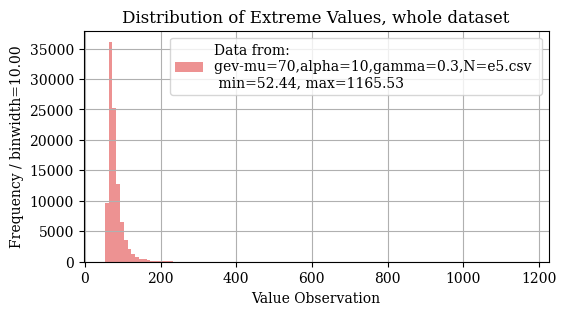

In [88]:

fig, ax_hist = plt.subplots(1, figsize=(6,3))


"""Histogram Plot"""
min_value = min(data)
max_value = max(data)
#n_bins = 50
bin_width = 10
n_bins = int((max_value - min_value) / bin_width)

ax_hist.hist(data, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.5, color=colors['VWLS'], label=f"Data from:\n{filename} \n min={min_value:.2f}, max={max_value:.2f}")
ax_hist.set_xlabel("Value Observation")
ax_hist.set_ylabel(f"Frequency / binwidth={bin_width:.2f}")
ax_hist.set_title("Distribution of Extreme Values, whole dataset")
ax_hist.grid()
ax_hist.legend(loc="upper right")


if save_figures:
    print("save")
    fig.savefig(f"{directory_figures}/Hist_{filename}.png")

save


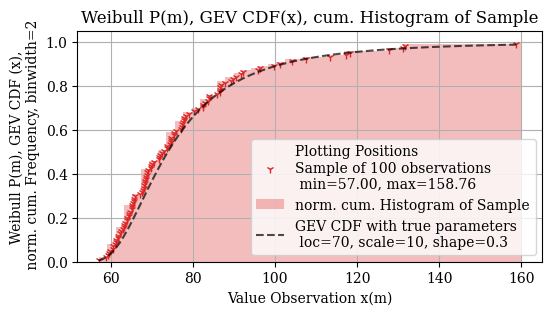

In [89]:

def weibull_plotting_positions(n):
    ranks = np.arange(1, n+1)
    P = ranks / (n + 1)
    return P

subdata=data[:100]
min_value = min(subdata)
max_value = max(subdata)
sorted_data = np.sort(subdata)
n = len(subdata)
ranks = np.arange(1, n + 1)
P = weibull_plotting_positions(n)

fig, ax_p = plt.subplots(1, figsize=(6,3))
ax_p.plot(sorted_data, P, marker=my_marker, linestyle='', color=colors['VWLS'], label=f"Plotting Positions\nSample of {n} observations\n min={min_value:.2f}, max={max_value:.2f}")
ax_p.hist(subdata, bins=50, density=True, range=(min_value,round(max_value,-1)), alpha=0.3, color=colors['VWLS'], label=f"norm. cum. Histogram of Sample", cumulative=True)

plot_data=np.linspace(min_value, max_value, 100)
cdf = genextreme.cdf(plot_data, c=-0.3, loc=70, scale=10)
ax_p.plot(plot_data, cdf, linestyle='--', alpha=0.7, color="black", label=f"GEV CDF with true parameters\n loc=70, scale=10, shape=0.3")

ax_p.set_ylabel("Weibull P(m), GEV CDF (x),\n norm. cum. Frequency, binwidth=2")
ax_p.set_xlabel("Value Observation x(m)")
ax_p.set_title("Weibull P(m), GEV CDF(x), cum. Histogram of Sample")
ax_p.grid()
ax_p.legend(loc="lower right")

if save_figures:
    print("save")
    fig.savefig(f"{directory_figures}/P,CDF,Hist_{filename}.png")

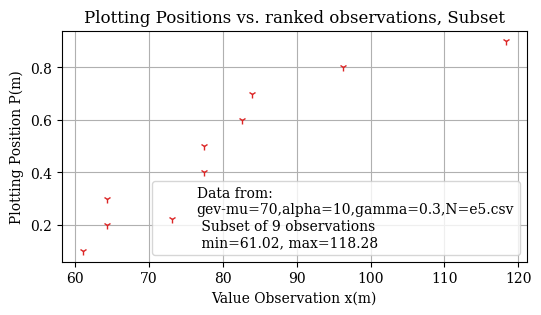

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))

"""Plotting Positions Plot"""
subdata=data[:9]
min_value = min(subdata)
max_value = max(subdata)
sorted_data = np.sort(subdata)
n = len(subdata)
ranks = np.arange(1, n + 1)
P = weibull_plotting_positions(n)
cdf = genextreme.cdf(sorted_data, c=0.3, loc=70, scale=10)
ax.plot(sorted_data, P, marker=my_marker, linestyle='', color=colors['VWLS'], label=f"Data from:\n{filename}\n Subset of {n} observations\n min={min_value:.2f}, max={max_value:.2f}")
#ax.plot(P, cdf, linestyle='--', alpha=0.7, color="black", label=f"GEV CDF with true parameters\n loc=70, scale=10, shape=0.3")
ax.set_xlabel("Value Observation x(m)")
ax.set_ylabel("Plotting Position P(m)")
ax.set_title("Plotting Positions vs. ranked observations, Subset")
#ax_p.set_yscale('log')
ax.grid()
ax.legend(loc="lower right")

if save_figures:
    fig.savefig(f"{directory_figures}/P_{filename}.png")